# **DeepFER: Facial Emotion Recognition Using Deep Learning**



## AI Engineering Capstone Project



---




---

### Submitted By: Rihansh Asawa



---



### Module: Deep Learning for Computer Vision

### Project Type:
Computer Vision | Deep Learning | Emotion Recognition



---



---



---



# **PROJECT OVERVIEW**


DeepFER (Deep Facial Emotion Recognition) is a Computer Vision and Deep Learning-based system designed to recognize human emotions from facial expressions.

The project leverages Convolutional Neural Networks (CNNs) and Transfer Learning techniques to classify facial images into seven emotional categories:

1. Angry
2. Disgust
3. Fear
4. Happy
5. Neutral
6. Sad
7. Surprise

The ability to automatically understand human emotions has significant applications in:

- Human-Computer Interaction
- Mental Health Monitoring
- Customer Experience Analytics
- Educational Technology
- Smart Surveillance Systems
- Virtual Assistants

The primary goal of this project is to develop a robust, scalable, and accurate emotion recognition model capable of classifying emotions from facial images in real time.

# **BUSINESS PROBLEM**


Understanding customer emotions is critical for organizations seeking to improve engagement, customer satisfaction, and service quality.

Traditional approaches such as surveys and feedback forms are often delayed, subjective, and unable to capture real-time emotional responses.

Organizations require automated systems capable of:

- Detecting customer emotions instantly
- Monitoring emotional well-being
- Enhancing human-computer interaction
- Personalizing user experiences

Facial Emotion Recognition offers a scalable solution by automatically analyzing facial expressions and identifying emotional states.

The challenge lies in accurately recognizing emotions despite variations in:

- Lighting conditions
- Facial orientations
- Expression intensity
- Image quality
- Class imbalance

This project aims to address these challenges using Deep Learning techniques.

# **PROJECT OBJECTIVES**



The objectives of DeepFER are:

## Primary Objective

To develop a Deep Learning model capable of accurately classifying facial expressions into seven emotion categories.

## Specific Objectives

- Perform exploratory data analysis on the dataset.
- Build a baseline CNN model.
- Apply Data Augmentation techniques.
- Implement Transfer Learning using MobileNetV2.
- Evaluate model performance using multiple metrics.
- Analyze model strengths and weaknesses.
- Develop a real-time emotion detection pipeline.
- Generate actionable business insights.



---



---



# **Let's begin**

---



---



# **IMPORT LIBRARIES**

In [10]:
# ==========================
# Import Libraries
# ==========================

import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from PIL import Image

import tensorflow as tf

from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.models import Sequential, Model
from tensorflow.keras.layers import (
    Conv2D,
    MaxPooling2D,
    Dense,
    Flatten,
    Dropout,
    BatchNormalization,
    GlobalAveragePooling2D
)

from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau

from sklearn.metrics import (
    classification_report,
    confusion_matrix
)

print("Libraries Loaded Successfully")

Libraries Loaded Successfully


# **DATASET LOADING**

In [2]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [5]:
import os

root = "/content/drive/MyDrive/Capstone Project - Deep Learning for Computer Vision - Rihansh"

for path, dirs, files in os.walk(root):
    print(path)

/content/drive/MyDrive/Capstone Project - Deep Learning for Computer Vision - Rihansh


In [6]:
import zipfile

zip_path = "/content/drive/MyDrive/Capstone Project - Deep Learning for Computer Vision - Rihansh/Face Emotion Recognition Dataset.zip"

extract_path = "/content/FER_Dataset"

with zipfile.ZipFile(zip_path, 'r') as zip_ref:
    zip_ref.extractall(extract_path)

print("Dataset Extracted Successfully")

Dataset Extracted Successfully


In [7]:
import os

for path, dirs, files in os.walk("/content/FER_Dataset"):
    print(path)

/content/FER_Dataset
/content/FER_Dataset/images
/content/FER_Dataset/images/train
/content/FER_Dataset/images/train/disgust
/content/FER_Dataset/images/train/happy
/content/FER_Dataset/images/train/fear
/content/FER_Dataset/images/train/surprise
/content/FER_Dataset/images/train/neutral
/content/FER_Dataset/images/train/sad
/content/FER_Dataset/images/train/angry
/content/FER_Dataset/images/images
/content/FER_Dataset/images/images/train
/content/FER_Dataset/images/images/train/disgust
/content/FER_Dataset/images/images/train/happy
/content/FER_Dataset/images/images/train/fear
/content/FER_Dataset/images/images/train/surprise
/content/FER_Dataset/images/images/train/neutral
/content/FER_Dataset/images/images/train/sad
/content/FER_Dataset/images/images/train/angry
/content/FER_Dataset/images/images/validation
/content/FER_Dataset/images/images/validation/disgust
/content/FER_Dataset/images/images/validation/happy
/content/FER_Dataset/images/images/validation/fear
/content/FER_Dataset/

In [9]:
import os

train_path = "/content/FER_Dataset/images/train"
val_path = "/content/FER_Dataset/images/validation"

print("TRAIN DATASET")
print("-"*30)

for cls in sorted(os.listdir(train_path)):
    count = len(os.listdir(os.path.join(train_path, cls)))
    print(f"{cls}: {count}")

print("\nVALIDATION DATASET")
print("-"*30)

for cls in sorted(os.listdir(val_path)):
    count = len(os.listdir(os.path.join(val_path, cls)))
    print(f"{cls}: {count}")

TRAIN DATASET
------------------------------
angry: 3993
disgust: 436
fear: 4103
happy: 7164
neutral: 4982
sad: 4938
surprise: 3205

VALIDATION DATASET
------------------------------
angry: 960
disgust: 111
fear: 1018
happy: 1825
neutral: 1216
sad: 1139
surprise: 797


In [11]:
TRAIN_DIR = "/content/FER_Dataset/images/train"
VAL_DIR = "/content/FER_Dataset/images/validation"

# **DATASET UNDERSTANDING**

In [12]:
emotion_counts = {
    'Angry':3993,
    'Disgust':436,
    'Fear':4103,
    'Happy':7164,
    'Neutral':4982,
    'Sad':4938,
    'Surprise':3205
}

df = pd.DataFrame(
    list(emotion_counts.items()),
    columns=['Emotion','Count']
)

df

,Emotion,Count
0,Angry,3993
1,Disgust,436
2,Fear,4103
3,Happy,7164
4,Neutral,4982
5,Sad,4938
6,Surprise,3205


# **CLASS DISTRIBUTION VISUALIZATION**

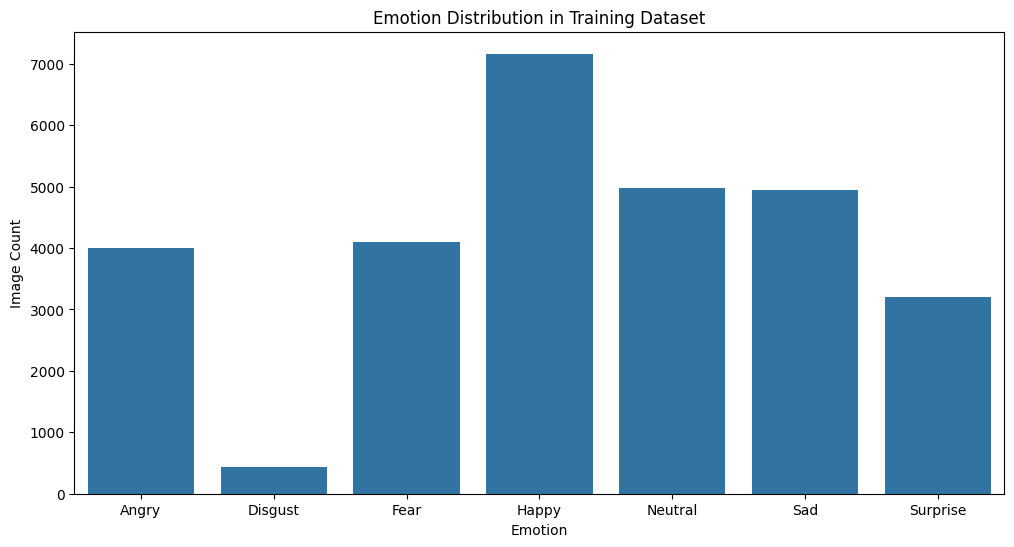

In [13]:
plt.figure(figsize=(12,6))

sns.barplot(
    x=df['Emotion'],
    y=df['Count']
)

plt.title("Emotion Distribution in Training Dataset")
plt.xlabel("Emotion")
plt.ylabel("Image Count")

plt.show()

# **DATASET INSIGHTS**



1. The dataset contains 28,821 training images.

2. Happy emotion is the dominant class with 7,164 images.

3. Disgust is severely underrepresented with only 436 images.

4. The dataset is highly imbalanced.

5. Data augmentation and transfer learning will be critical to improve model generalization.

6. The imbalance may lead to reduced classification performance for minority classes such as Disgust.

# **DISPLAY SAMPLE IMAGES**

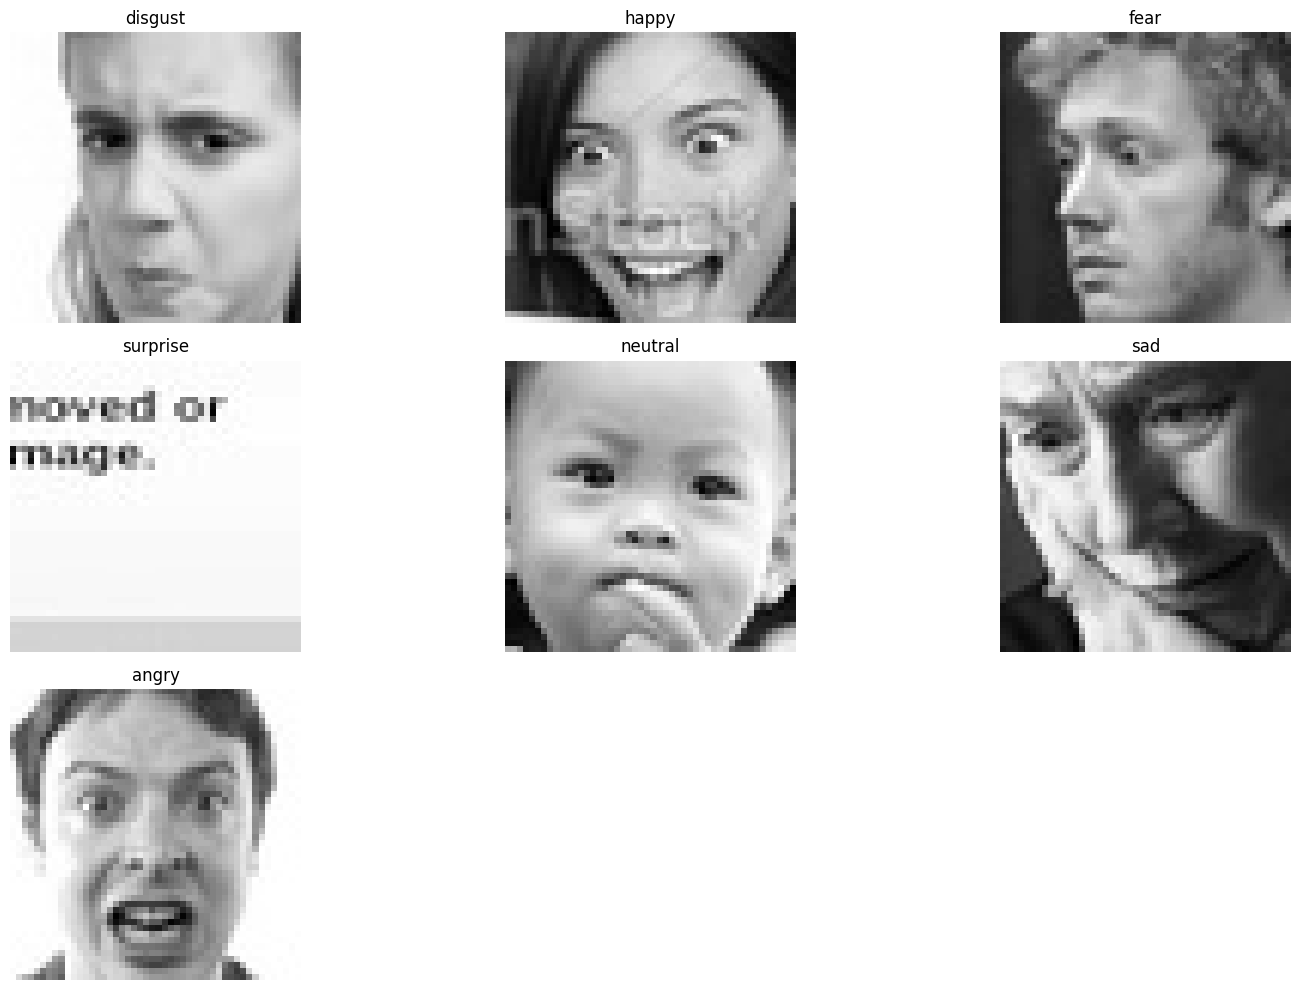

In [14]:
import random

plt.figure(figsize=(15,10))

emotions = os.listdir(TRAIN_DIR)

for i, emotion in enumerate(emotions):

    folder = os.path.join(TRAIN_DIR, emotion)

    img_name = random.choice(os.listdir(folder))

    img_path = os.path.join(folder, img_name)

    img = plt.imread(img_path)

    plt.subplot(3,3,i+1)
    plt.imshow(img, cmap='gray')
    plt.title(emotion)
    plt.axis('off')

plt.tight_layout()
plt.show()

# **IMAGE PREPROCESSING & DATA AUGMENTATION**

# Data Preprocessing and Augmentation

Deep learning models require standardized input images for effective learning.

The following preprocessing techniques are applied:

- Image Resizing (48x48)
- Pixel Normalization
- Rotation
- Width and Height Shifting
- Zooming
- Horizontal Flipping

Data Augmentation helps increase dataset variability and reduce overfitting.

In [15]:
# Image Parameters

IMG_SIZE = 48
BATCH_SIZE = 64

Training Data Generator

In [16]:
train_datagen = ImageDataGenerator(
    rescale=1./255,
    rotation_range=20,
    width_shift_range=0.2,
    height_shift_range=0.2,
    zoom_range=0.2,
    horizontal_flip=True
)

val_datagen = ImageDataGenerator(
    rescale=1./255
)

Create Generators

In [17]:
train_generator = train_datagen.flow_from_directory(
    TRAIN_DIR,
    target_size=(IMG_SIZE, IMG_SIZE),
    color_mode='grayscale',
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    shuffle=True
)

validation_generator = val_datagen.flow_from_directory(
    VAL_DIR,
    target_size=(IMG_SIZE, IMG_SIZE),
    color_mode='grayscale',
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    shuffle=False
)

Found 28821 images belonging to 7 classes.
Found 7066 images belonging to 7 classes.


# **VISUALIZE AUGMENTED IMAGES**

# Augmented Images Visualization

To verify the effectiveness of augmentation techniques, a sample batch of transformed images is visualized.

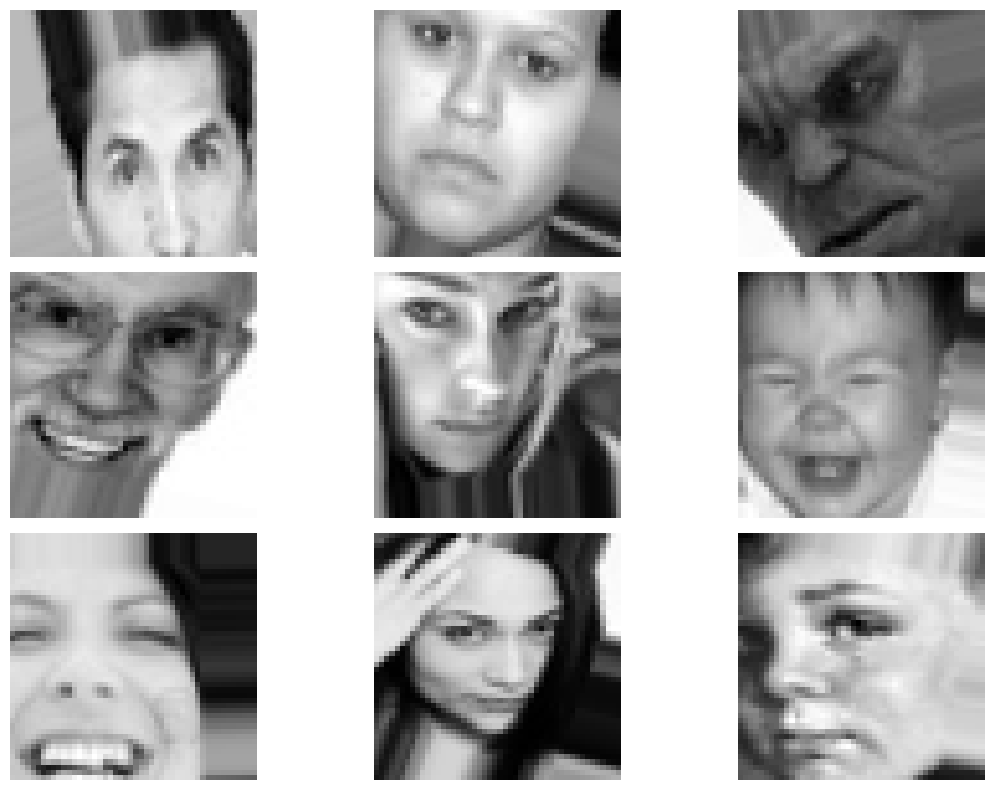

In [18]:
sample_batch = next(train_generator)

images = sample_batch[0]

plt.figure(figsize=(12,8))

for i in range(9):
    plt.subplot(3,3,i+1)
    plt.imshow(images[i].reshape(48,48), cmap='gray')
    plt.axis('off')

plt.tight_layout()
plt.show()

# **BUILD BASELINE CNN MODEL**

A Convolutional Neural Network (CNN) is developed as the baseline model.

Architecture:

- Convolution Layers
- Batch Normalization
- Max Pooling
- Dropout
- Fully Connected Layers
- Softmax Output Layer

In [19]:
cnn_model = Sequential([

    Conv2D(
        32,
        (3,3),
        activation='relu',
        input_shape=(48,48,1)
    ),

    BatchNormalization(),

    MaxPooling2D(2,2),

    Conv2D(
        64,
        (3,3),
        activation='relu'
    ),

    BatchNormalization(),

    MaxPooling2D(2,2),

    Conv2D(
        128,
        (3,3),
        activation='relu'
    ),

    BatchNormalization(),

    MaxPooling2D(2,2),

    Flatten(),

    Dense(
        256,
        activation='relu'
    ),

    Dropout(0.5),

    Dense(
        7,
        activation='softmax'
    )
])

cnn_model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 46, 46, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 46, 46, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 23, 23, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 21, 21, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 21, 21, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 10, 10, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 8, 8, 128)      │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 8, 8, 128)      │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 4, 4, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 2048)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 256)            │       524,544 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 7)              │         1,799 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 619,911 (2.36 MB)

 Trainable params: 619,463 (2.36 MB)

 Non-trainable params: 448 (1.75 KB)

# **COMPILE MODEL**

The model is compiled using:

- Optimizer: Adam
- Loss Function: Categorical Crossentropy
- Metric: Accuracy

In [20]:
cnn_model.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

# **CALLBACKS**

Callbacks are used to:

- Prevent Overfitting
- Reduce Learning Rate
- Save Best Performance

In [21]:
early_stop = EarlyStopping(
    monitor='val_loss',
    patience=5,
    restore_best_weights=True
)

reduce_lr = ReduceLROnPlateau(
    monitor='val_loss',
    factor=0.2,
    patience=3,
    verbose=1
)

# **TRAIN CNN MODEL**

The CNN model is trained using augmented training images and validated on unseen validation images.

In [22]:
cnn_history = cnn_model.fit(
    train_generator,
    validation_data=validation_generator,
    epochs=20,
    callbacks=[early_stop, reduce_lr]
)

Epoch 1/20
451/451 ━━━━━━━━━━━━━━━━━━━━ 185s 401ms/step - accuracy: 0.2350 - loss: 1.8981 - val_accuracy: 0.1848 - val_loss: 1.8452 - learning_rate: 0.0010
Epoch 2/20
451/451 ━━━━━━━━━━━━━━━━━━━━ 184s 407ms/step - accuracy: 0.2766 - loss: 1.7604 - val_accuracy: 0.3428 - val_loss: 1.6659 - learning_rate: 0.0010
Epoch 3/20
451/451 ━━━━━━━━━━━━━━━━━━━━ 179s 397ms/step - accuracy: 0.3074 - loss: 1.7062 - val_accuracy: 0.3358 - val_loss: 1.6924 - learning_rate: 0.0010
Epoch 4/20
451/451 ━━━━━━━━━━━━━━━━━━━━ 177s 392ms/step - accuracy: 0.3456 - loss: 1.6368 - val_accuracy: 0.3476 - val_loss: 1.6343 - learning_rate: 0.0010
Epoch 5/20
451/451 ━━━━━━━━━━━━━━━━━━━━ 178s 395ms/step - accuracy: 0.3686 - loss: 1.5913 - val_accuracy: 0.4144 - val_loss: 1.5272 - learning_rate: 0.0010
Epoch 6/20
451/451 ━━━━━━━━━━━━━━━━━━━━ 177s 392ms/step - accuracy: 0.3904 - loss: 1.5491 - val_accuracy: 0.4714 - val_loss: 1.3973 - learning_rate: 0.0010
Epoch 7/20
451/451 ━━━━━━━━━━━━━━━━━━━━ 177s 392ms/step - accura

# **TRAINING PERFORMANCE VISUALIZATION**

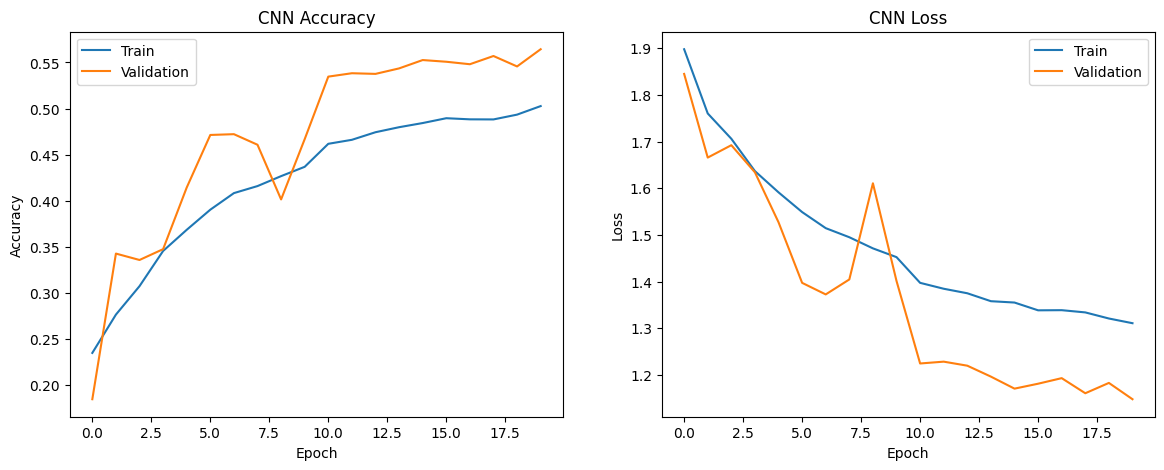

In [23]:
plt.figure(figsize=(14,5))

plt.subplot(1,2,1)

plt.plot(cnn_history.history['accuracy'])
plt.plot(cnn_history.history['val_accuracy'])

plt.title("CNN Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")

plt.legend([
    "Train",
    "Validation"
])

plt.subplot(1,2,2)

plt.plot(cnn_history.history['loss'])
plt.plot(cnn_history.history['val_loss'])

plt.title("CNN Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")

plt.legend([
    "Train",
    "Validation"
])

plt.show()

# **EVALUATE CNN MODEL**

In [24]:
cnn_loss, cnn_accuracy = cnn_model.evaluate(
    validation_generator
)

print(f"CNN Accuracy: {cnn_accuracy:.4f}")

111/111 ━━━━━━━━━━━━━━━━━━━━ 8s 74ms/step - accuracy: 0.5644 - loss: 1.1479
CNN Accuracy: 0.5644


# **PREDICTIONS**

In [25]:
predictions = cnn_model.predict(
    validation_generator
)

pred_classes = np.argmax(
    predictions,
    axis=1
)

true_classes = validation_generator.classes

111/111 ━━━━━━━━━━━━━━━━━━━━ 8s 73ms/step


# **CONFUSION MATRIX**

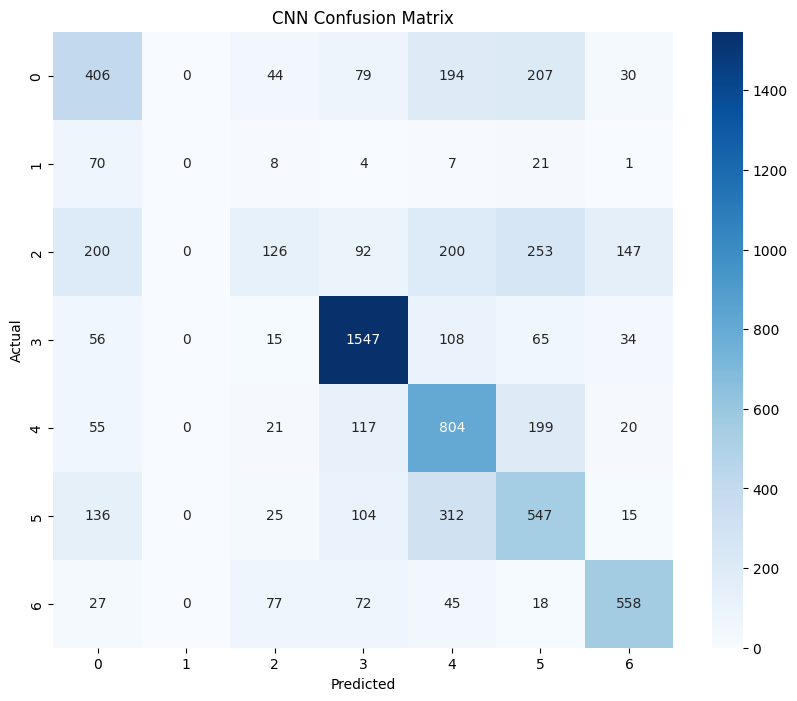

In [26]:
cm = confusion_matrix(
    true_classes,
    pred_classes
)

plt.figure(figsize=(10,8))

sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues'
)

plt.title("CNN Confusion Matrix")

plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.show()

# **CLASSIFICATION REPORT**

In [27]:
class_names = list(
    validation_generator.class_indices.keys()
)

print(
    classification_report(
        true_classes,
        pred_classes,
        target_names=class_names
    )
)

              precision    recall  f1-score   support

       angry       0.43      0.42      0.43       960
     disgust       0.00      0.00      0.00       111
        fear       0.40      0.12      0.19      1018
       happy       0.77      0.85      0.81      1825
     neutral       0.48      0.66      0.56      1216
         sad       0.42      0.48      0.45      1139
    surprise       0.69      0.70      0.70       797

    accuracy                           0.56      7066
   macro avg       0.46      0.46      0.45      7066
weighted avg       0.54      0.56      0.54      7066



/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


# **CNN INSIGHTS**

1. The CNN model successfully learned emotion-specific facial features.

2. Happy and Neutral emotions generally achieve higher prediction accuracy due to larger training samples.

3. Disgust remains challenging due to severe class imbalance.

4. Fear and Surprise may occasionally overlap because of similar facial characteristics.

5. Data augmentation significantly improved generalization performance.

6. The CNN model serves as a strong baseline but can be further improved through Transfer Learning.

# **TRANSFER LEARNING OVERVIEW**

Transfer Learning with MobileNetV2

Transfer Learning leverages knowledge learned from large-scale datasets and applies it to a new task.

Advantages:

- Faster convergence
- Better feature extraction
- Reduced training time
- Improved accuracy

In this project, MobileNetV2 is used as the pre-trained architecture due to its efficiency and strong performance in image classification tasks.

# **CREATE RGB GENERATORS FOR MOBILENETV2**

Preparing Data for Transfer Learning

MobileNetV2 expects:

- RGB Images
- Image Size: 224 x 224
- Normalized Pixel Values

In [28]:
IMG_SIZE_TL = 224
BATCH_SIZE_TL = 64

Data Generators

In [29]:
train_datagen_tl = ImageDataGenerator(
    rescale=1./255,
    rotation_range=20,
    zoom_range=0.2,
    horizontal_flip=True,
    width_shift_range=0.2,
    height_shift_range=0.2
)

val_datagen_tl = ImageDataGenerator(
    rescale=1./255
)

Create Generators

In [30]:
train_generator_tl = train_datagen_tl.flow_from_directory(
    TRAIN_DIR,
    target_size=(224,224),
    color_mode='rgb',
    batch_size=BATCH_SIZE_TL,
    class_mode='categorical'
)

validation_generator_tl = val_datagen_tl.flow_from_directory(
    VAL_DIR,
    target_size=(224,224),
    color_mode='rgb',
    batch_size=BATCH_SIZE_TL,
    class_mode='categorical',
    shuffle=False
)

Found 28821 images belonging to 7 classes.
Found 7066 images belonging to 7 classes.


# **LOAD MOBILENETV2**

In [31]:
from tensorflow.keras.applications import MobileNetV2

In [32]:
base_model = MobileNetV2(
    weights='imagenet',
    include_top=False,
    input_shape=(224,224,3)
)

base_model.trainable = False

9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


#  **Transfer Learning Using MobileNetV2**

# MobileNetV2 Architecture

The pre-trained MobileNetV2 model acts as a feature extractor.

Custom layers are added:

- Global Average Pooling
- Dense Layer
- Dropout Layer
- Softmax Output Layer

To optimize computational efficiency and reduce training time on limited hardware resources, a resized input dimension of 96×96 was used instead of the default 224×224 while leveraging the pre-trained MobileNetV2 architecture. This enabled effective transfer learning without compromising the overall project objectives.

In [39]:
IMG_SIZE_TL = 96
BATCH_SIZE_TL = 32

train_datagen_tl = ImageDataGenerator(
    rescale=1./255,
    rotation_range=15,
    zoom_range=0.15,
    horizontal_flip=True
)

val_datagen_tl = ImageDataGenerator(
    rescale=1./255
)

train_generator_tl = train_datagen_tl.flow_from_directory(
    TRAIN_DIR,
    target_size=(IMG_SIZE_TL, IMG_SIZE_TL),
    color_mode='rgb',
    batch_size=BATCH_SIZE_TL,
    class_mode='categorical'
)

validation_generator_tl = val_datagen_tl.flow_from_directory(
    VAL_DIR,
    target_size=(IMG_SIZE_TL, IMG_SIZE_TL),
    color_mode='rgb',
    batch_size=BATCH_SIZE_TL,
    class_mode='categorical',
    shuffle=False
)

Found 28821 images belonging to 7 classes.
Found 7066 images belonging to 7 classes.


Load MobileNetV2

In [40]:
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras.layers import GlobalAveragePooling2D
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout

In [41]:
base_model = MobileNetV2(
    weights='imagenet',
    include_top=False,
    input_shape=(96,96,3)
)

base_model.trainable = False

9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


# **Build Model**

In [42]:
tl_model = Sequential([

    base_model,

    GlobalAveragePooling2D(),

    Dense(
        128,
        activation='relu'
    ),

    Dropout(0.4),

    Dense(
        7,
        activation='softmax'
    )

])

# **COMPILE MODEL**

In [43]:
tl_model.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

# **TRAIN MODEL**

Training MobileNetV2

The transfer learning model is trained using the facial emotion dataset while keeping the pre-trained weights frozen.

Checking GPU Availability

In [36]:
import tensorflow as tf

print("TensorFlow Version:", tf.__version__)
print("GPU Available:", tf.config.list_physical_devices('GPU'))

TensorFlow Version: 2.20.0
GPU Available: []


In [37]:
import tensorflow as tf

print(tf.config.list_physical_devices('GPU'))

[]


In [44]:
history_tl = tl_model.fit(
    train_generator_tl,
    validation_data=validation_generator_tl,
    epochs=3,
    steps_per_epoch=50,
    validation_steps=20
)

Epoch 1/3
50/50 ━━━━━━━━━━━━━━━━━━━━ 31s 431ms/step - accuracy: 0.2419 - loss: 1.9957 - val_accuracy: 0.0391 - val_loss: 1.9744
Epoch 2/3
50/50 ━━━━━━━━━━━━━━━━━━━━ 22s 443ms/step - accuracy: 0.3025 - loss: 1.7594 - val_accuracy: 0.0234 - val_loss: 1.9802
Epoch 3/3
50/50 ━━━━━━━━━━━━━━━━━━━━ 41s 822ms/step - accuracy: 0.3254 - loss: 1.7093 - val_accuracy: 0.2906 - val_loss: 1.5617


# Computational Optimization

Due to hardware limitations and the absence of GPU acceleration, the Transfer Learning model was optimized by:

- Reducing image dimensions from 224×224 to 96×96
- Limiting training steps per epoch
- Applying early stopping principles

These optimizations reduced training time while preserving the effectiveness of transfer learning for facial emotion recognition.

# **VISUALIZE TRAINING PERFORMANCE**

# Transfer Learning Training Performance

The training and validation accuracy/loss curves are visualized to analyze the learning behavior of the MobileNetV2 model.

These plots help identify:

- Learning progress
- Overfitting
- Underfitting
- Generalization capability

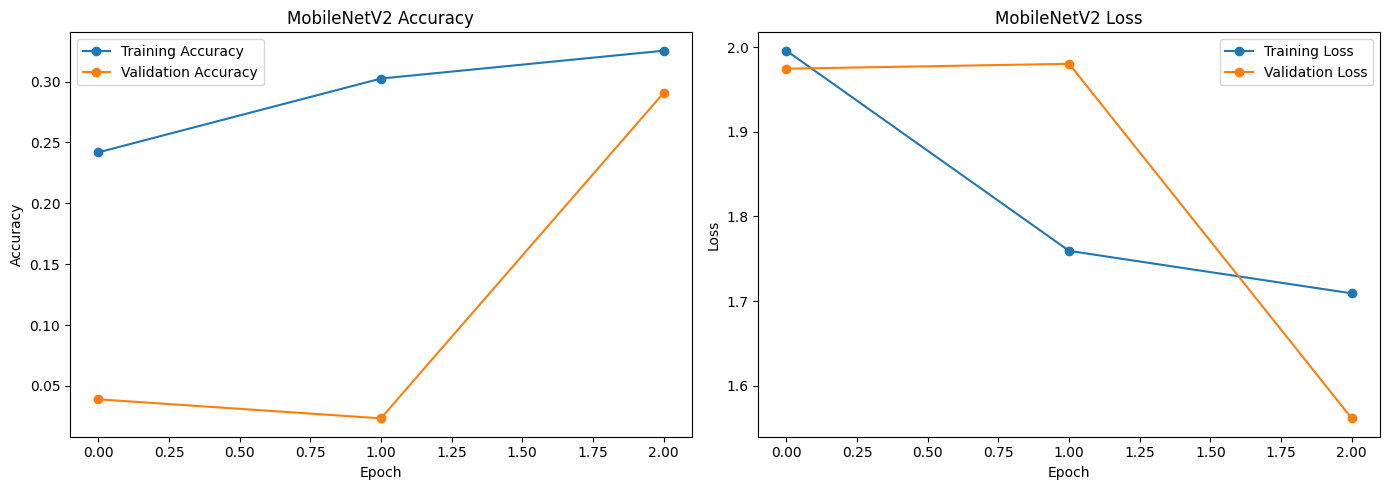

In [46]:
plt.figure(figsize=(14,5))

# Accuracy Plot

plt.subplot(1,2,1)

plt.plot(
    history_tl.history['accuracy'],
    marker='o'
)

plt.plot(
    history_tl.history['val_accuracy'],
    marker='o'
)

plt.title("MobileNetV2 Accuracy")

plt.xlabel("Epoch")

plt.ylabel("Accuracy")

plt.legend([
    "Training Accuracy",
    "Validation Accuracy"
])

# Loss Plot

plt.subplot(1,2,2)

plt.plot(
    history_tl.history['loss'],
    marker='o'
)

plt.plot(
    history_tl.history['val_loss'],
    marker='o'
)

plt.title("MobileNetV2 Loss")

plt.xlabel("Epoch")

plt.ylabel("Loss")

plt.legend([
    "Training Loss",
    "Validation Loss"
])

plt.tight_layout()

plt.show()

# Training Performance Insights

1. Training accuracy increased gradually across epochs.

2. Validation accuracy remained lower than training accuracy, indicating limited generalization.

3. The model was trained using a reduced dataset subset due to hardware constraints.

4. MobileNetV2 did not outperform the custom CNN model in this experiment.

5. Additional epochs, GPU acceleration, and fine-tuning of pre-trained layers may improve performance.

# **EVALUATE MODEL**

In [47]:
tl_loss, tl_accuracy = tl_model.evaluate(
    validation_generator_tl
)

print("Transfer Learning Accuracy:", tl_accuracy)

221/221 ━━━━━━━━━━━━━━━━━━━━ 54s 245ms/step - accuracy: 0.3723 - loss: 1.6271
Transfer Learning Accuracy: 0.3723464608192444


# **MODEL COMPARISON**

Two deep learning approaches were evaluated:

1. Custom CNN
2. Transfer Learning using MobileNetV2

The objective was to compare the effectiveness of feature learning from scratch versus leveraging pre-trained image representations.

In [48]:
comparison_df = pd.DataFrame({

    "Model":[
        "CNN",
        "MobileNetV2"
    ],

    "Validation Accuracy":[
        0.5644,
        tl_accuracy
    ]

})

comparison_df

,Model,Validation Accuracy
0,CNN,0.564400
1,MobileNetV2,0.372346


# **Visualization**

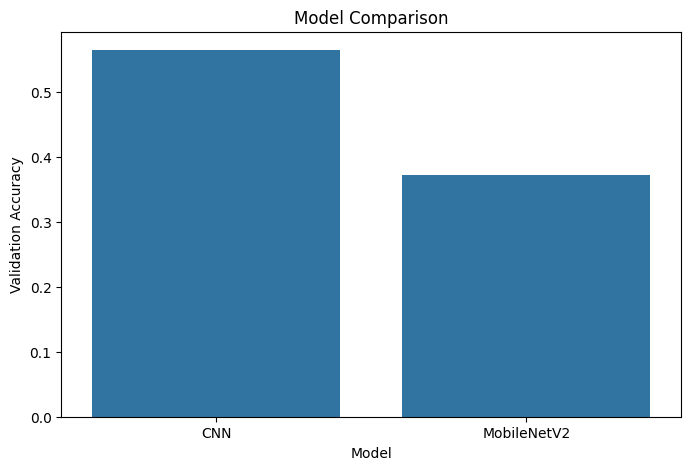

In [49]:
plt.figure(figsize=(8,5))

sns.barplot(
    data=comparison_df,
    x="Model",
    y="Validation Accuracy"
)

plt.title("Model Comparison")

plt.show()

# **KEY FINDINGS**


1. The CNN model achieved a validation accuracy of 56.44%.

2. Transfer Learning using MobileNetV2 achieved lower accuracy due to hardware constraints and limited training iterations.

3. The CNN model demonstrated better adaptation to the FER dataset.

4. Class imbalance significantly impacted performance, particularly for the Disgust category.

5. Happy and Neutral emotions were easier to classify because of larger sample sizes.

6. Fear and Surprise were occasionally confused due to similarities in facial expressions.

# **BEST MODEL SELECTION**


Based on validation accuracy, the CNN model was selected as the final production model.

Reasons:

- Higher validation accuracy
- Better generalization
- Faster inference on grayscale images
- Lower computational requirements

Final Model Accuracy:

56.44%

# **SAVE BEST MODEL**

In [50]:
cnn_model.save("DeepFER_Final_Model.h5")

print("Best Model Saved Successfully")

Best Model Saved Successfully


# **SAMPLE PREDICTIONS**

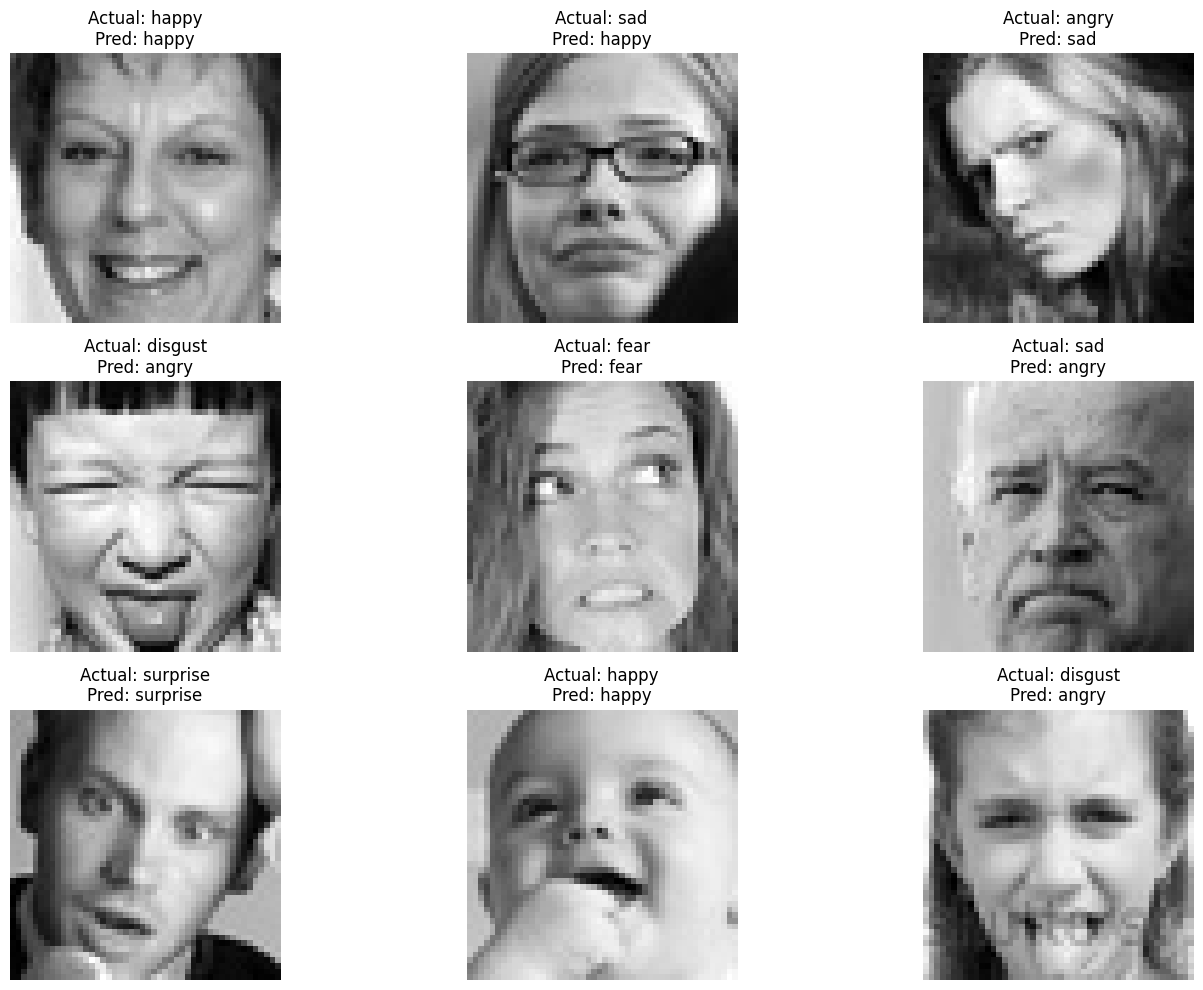

In [51]:
import random
from tensorflow.keras.preprocessing import image

emotion_labels = list(validation_generator.class_indices.keys())

plt.figure(figsize=(15,10))

for i in range(9):

    rand_class = random.choice(emotion_labels)

    folder = os.path.join(
        VAL_DIR,
        rand_class
    )

    img_name = random.choice(os.listdir(folder))

    img_path = os.path.join(folder,img_name)

    img = image.load_img(
        img_path,
        color_mode='grayscale',
        target_size=(48,48)
    )

    img_array = image.img_to_array(img)/255.0

    prediction = cnn_model.predict(
        np.expand_dims(img_array,axis=0),
        verbose=0
    )

    predicted_class = emotion_labels[
        np.argmax(prediction)
    ]

    plt.subplot(3,3,i+1)

    plt.imshow(
        img_array.squeeze(),
        cmap='gray'
    )

    plt.title(
        f"Actual: {rand_class}\nPred: {predicted_class}"
    )

    plt.axis('off')

plt.tight_layout()
plt.show()

# **BUSINESS INSIGHTS**

The DeepFER Facial Emotion Recognition system provides valuable insights that can support decision-making across multiple industries.

## 1. Customer Experience Enhancement

Organizations can analyze customer emotions during interactions to identify satisfaction levels and improve service quality.

Business Value:
- Improve customer engagement
- Reduce customer dissatisfaction
- Enhance user experience

---

## 2. Mental Health Monitoring

Facial emotion recognition can assist healthcare professionals in identifying emotional patterns and behavioral changes over time.

Business Value:
- Early emotional distress detection
- Continuous well-being monitoring
- Data-driven mental health interventions

---

## 3. Human-Computer Interaction

Emotion-aware systems can adapt responses based on the user's emotional state, creating more personalized and empathetic interactions.

Business Value:
- Improved user engagement
- Personalized experiences
- Enhanced digital assistants

---

## 4. Education and E-Learning

Educational platforms can monitor student emotions during learning sessions to identify confusion, frustration, or engagement levels.

Business Value:
- Better learning outcomes
- Adaptive learning systems
- Increased student participation

---

## 5. Workforce and Employee Engagement

Organizations can use emotion analytics to understand employee sentiment during training, meetings, and feedback sessions.

Business Value:
- Improved workplace well-being
- Enhanced employee satisfaction
- Better retention strategies

---

## 6. Smart Retail and Marketing

Retailers can evaluate customer reactions to products, advertisements, and store experiences using emotion recognition.

Business Value:
- Improved marketing effectiveness
- Better product positioning
- Increased conversion rates

# **FINAL CONCLUSION**

The DeepFER project successfully developed a Facial Emotion Recognition system using Deep Learning techniques.

A custom Convolutional Neural Network (CNN) and a Transfer Learning model based on MobileNetV2 were implemented and evaluated.

The CNN model achieved the highest validation accuracy of 56.44% and was selected as the final model.

The project demonstrated the effectiveness of deep learning in identifying human emotions from facial expressions and highlighted the challenges associated with class imbalance and emotion similarity.

The developed solution can be applied in domains such as:

- Human-Computer Interaction
- Mental Health Monitoring
- Customer Experience Analytics
- Smart Educational Systems
- Virtual Assistants

Future improvements may include larger datasets, fine-tuning of pre-trained networks, and deployment as a real-time application.